<a href="https://colab.research.google.com/github/SEnvironment/AIML_Winnovation_2026_Regression_Project/blob/main/Alok_Regression_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Model On Fridge Price Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member -** Alok
**Class** - CSE-DS


**Batch** - 2024-28

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

https://github.com/SEnvironment/AIML_Winnovation_2026_Regression_Project/blob/main/Alok_Regression_ML_Submission_Template.ipynb

# **Problem Statement**


We need to analyse the fridge Price Dataset and make a model which predict the price of dataset.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

### Dataset Loading

In [3]:
# Load Dataset
fp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA SETs/fridge_price_predictor_dataset_real_brands.csv')

### Dataset First View

In [4]:
# Dataset First Lookfp
fp.head()

,Brand,Model,Capacity,Energy Rating,Type,Features,Color,Material,Warranty Period,Country of Manufacture,Price,Random Numeric Feature 1,Random Text Feature 2,Irrelevant Category Feature 3
0,Panasonic,Model0,369.0,A++,NaN,NaN,NaN,Stainless Steel,5.0,Germany,1231.0,3984.0,Text0,Category3
1,GE,Model1,619.0,A,Side-by-Side,Smart Connectivity,White,Glass,8.0,Germany,267.0,3155.0,Text1,Category3
2,GE,Model2,309.0,A,Single Door,Ice Dispenser,Black,Stainless Steel,7.0,India,477.0,2218.0,Text2,Category2
3,LG,Model3,662.0,B,Side-by-Side,Ice Dispenser,Gray,Plastic,8.0,India,NaN,4734.0,Text3,Category2
4,Bosch,Model4,533.0,B,Double Door,Water Dispenser,Gray,Plastic,NaN,India,993.0,4259.0,Text4,Category1


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
fp.shape

(20000, 14)

### Dataset Information

In [6]:
# Dataset Info
fp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Brand                          20000 non-null  object 
 1   Model                          19000 non-null  object 
 2   Capacity                       19012 non-null  float64
 3   Energy Rating                  19000 non-null  object 
 4   Type                           19000 non-null  object 
 5   Features                       14226 non-null  object 
 6   Color                          19000 non-null  object 
 7   Material                       19000 non-null  object 
 8   Warranty Period                19000 non-null  float64
 9   Country of Manufacture         19000 non-null  object 
 10  Price                          19000 non-null  float64
 11  Random Numeric Feature 1       19000 non-null  float64
 12  Random Text Feature 2          19000 non-null 

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
fp.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
fp.isnull().sum()

,0
Brand,0
Model,1000
Capacity,988
Energy Rating,1000
Type,1000
Features,5774
Color,1000
Material,1000
Warranty Period,1000
Country of Manufacture,1000


In [9]:
# Visualizing the missing values
print(fp.isnull())

       Brand  Model  Capacity  Energy Rating   Type  Features  Color  \
0      False  False     False          False   True      True   True   
1      False  False     False          False  False     False  False   
2      False  False     False          False  False     False  False   
3      False  False     False          False  False     False  False   
4      False  False     False          False  False     False  False   
...      ...    ...       ...            ...    ...       ...    ...   
19995  False  False     False          False  False      True  False   
19996  False  False     False          False  False     False  False   
19997  False  False     False          False  False      True  False   
19998  False  False      True          False  False     False  False   
19999  False  False     False          False  False     False  False   

       Material  Warranty Period  Country of Manufacture  Price  \
0         False            False                   False  False   
1

### What did you know about your dataset?

Data set have total 20,000 rows and 14 columns which have not any duplicate value present in it. Year,state and seller have not any missing value in it.

Data set have average 1000 null value in every column .Answer Here

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
fp.columns

Index(['Brand', 'Model', 'Capacity', 'Energy Rating', 'Type', 'Features',
       'Color', 'Material', 'Warranty Period', 'Country of Manufacture',
       'Price', 'Random Numeric Feature 1', 'Random Text Feature 2',
       'Irrelevant Category Feature 3'],
      dtype='object')

In [11]:
# Dataset Describe
fp.describe()

,Capacity,Warranty Period,Price,Random Numeric Feature 1
count,19012.000000,19000.000000,19000.000000,19000.000000
mean,447.283032,5.022842,1099.181684,2994.733263
std,207.008095,2.575806,518.876706,1152.089268
min,-99.000000,1.000000,200.000000,1000.000000
25%,272.000000,3.000000,649.000000,1990.750000
50%,449.000000,5.000000,1099.000000,2987.000000
75%,626.000000,7.000000,1552.000000,3982.250000
max,799.000000,9.000000,1999.000000,4999.000000


### Variables Description


**Brand** - Brand name of the refrigerator (e.g., LG, Samsung, Whirlpool).

**Model** -  Model number or name of the refrigerator.

**Capacity** - Storage capacity of the refrigerator in liters (L).


**Energy Rating** - Energy efficiency rating of the refrigerator (e.g., 1-Star to 5-Star).

**Type** - Type of refrigerator (Single Door, Double Door, Side-by-Side, French Door, etc.).

**Features** - Special features available in the refrigerator (Frost Free, Inverter Compressor, Convertible, Smart Features, etc.).

**Color** - Exterior color of the refrigerator.

**Material** - Material used for the refrigerator body or finish.

**Warranty Period** - Warranty provided by the manufacturer (in years).

**Country of Manufacture** - Country where the refrigerator is manufactured.

**Price** -  Selling price of the refrigerator (Target Variable).

**Random Numeric Feature 1** - Artificial numerical feature added to the dataset for experimentation; not useful for price prediction.

**Random Text Feature 2** - Artificial text feature added for testing preprocessing techniques; not relevant to prediction.

**Irrelevant Category Feature 3** - Artificial categorical feature with no meaningful relationship to refrigerator price.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
col = fp.columns.to_list()
for  i in col:
  print(f'{i} = {fp[i].unique()} \n')

Brand = ['Panasonic' 'GE' 'LG' 'Bosch' 'Siemens' 'Haier' 'Samsung' 'Frigidaire'
 'Electrolux' 'Whirlpool' 'Br@ndX'] 

Model = ['Model0' 'Model1' 'Model2' ... 'Model19997' 'Model19998' 'Model19999'] 

Capacity = [369. 619. 309. 662. 533. 371. 288. 671. 492. 287. 529. 647. 621. 342.
 198. 680. 557. 224. 749. 455. 515. 594.  nan 679. 477. 746. 730. 275.
 692. 435. 751.  -9. 789. 150. 365. 149. 447. 661. 726. 245. 443. 632.
 405. 736. 590. 419. 327. 164. 469. 616. 748. 495. 221. 406. 449. 252.
 339. 694. 348. 420. 303. 109. 777. 643. 132. 627. 301. 223. 177. 353.
 453. 279. 157. 787. 376. 759. 416. 766. 422. 795. 750. 660. 499. 148.
 297. 635. 568. 191. 657. 333. 705. 721. 108. 765. 103. 505. 708. 407.
 304. 117. 292. 716. 397. 401. 340. 229. 284. 409. 120. 236. 790. 166.
 121. 783. 386. 667. 257. 703. 608. 755. 467. 168. 502. 672. 702. 337.
 648. 140. 485. 338. 588. 596. 377. 593. 646. 359. 664. 402. 639. 503.
 474. 115. 178. 218. 364. 480. 496. 727. 225. 391. 560. 613. 101. 744.
 363. 61

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

In [14]:
fp = fp.drop(columns=['Model'])

In [15]:
fp = fp.drop(columns=['Random Text Feature 2'])

In [16]:
fp['Warranty Period'] = fp['Warranty Period'].fillna(5)

In [17]:
fp['Capacity'] = fp['Capacity'].fillna(447)

In [18]:
fp['Energy Rating'] = fp['Energy Rating'].fillna('No1')

In [19]:
fp['Type'] = fp['Type'].fillna('No2')

In [20]:
fp['Features'] = fp['Features'].fillna('No3')

In [21]:
fp['Color'] = fp['Color'].fillna('No4')

In [22]:
fp['Material'] = fp['Material'].fillna('No5')

In [23]:
fp['Country of Manufacture'] = fp['Country of Manufacture'].fillna('No6')

In [24]:
fp['Price'] = fp['Price'].fillna(1099)

In [25]:
fp['Random Numeric Feature 1'] = fp['Random Numeric Feature 1'].fillna(2987)

In [26]:
fp['Irrelevant Category Feature 3'] = fp['Irrelevant Category Feature 3'].fillna('No7')

### What all manipulations have you done and insights you found?

Answer Here.

### Data Manipulations and Insights:

**1. Column Dropping:**
*   **'Model' column:** This column was dropped, likely because it contains highly granular data (specific model numbers) which could lead to high cardinality, making it difficult to use directly for modeling or potentially increasing model complexity without significant predictive power. It might also have been deemed irrelevant or redundant if 'Brand' and 'Features' sufficiently capture the necessary information.
*   **'Random Text Feature 2' column:** This column was dropped explicitly because it was identified as an 'Artificial text feature added for testing preprocessing techniques; not relevant to prediction.' This is a good step to remove irrelevant features that do not contribute to the target variable prediction.

**2. Missing Value Imputation (Numerical Features):**
*   **'Warranty Period'**: Missing values were filled with `5`. This could be the mode, median, or a reasonable default warranty period if not specified.
*   **'Capacity'**: Missing values were filled with `447`. This is likely the mean or median capacity, providing a central tendency for missing values.
*   **'Price'**: Missing values were filled with `1099`. This is the target variable, and imputing missing prices is crucial for a complete dataset. The value chosen might represent a median or mean price to avoid bias.
*   **'Random Numeric Feature 1'**: Missing values were filled with `2987`. Similar to other numerical features, this ensures no missing values remain in this column.

**3. Missing Value Imputation (Categorical Features):**
*   **'Energy Rating'**, **'Type'**, **'Features'**, **'Color'**, **'Material'**, **'Country of Manufacture'**, and **'Irrelevant Category Feature 3'**: Missing values in these categorical columns were filled with placeholder strings like 'No1', 'No2', ..., 'No7'. This approach effectively treats missingness as its own category. This can be useful for categorical features, as it preserves the information that a value was originally missing, rather than inferring a value that might not be accurate.

### Overall Insights from Wrangling:
*   The dataset contained several columns with missing values across both numerical and categorical types.
*   A conscious decision was made to remove irrelevant features to streamline the dataset for modeling.
*   Missing values were handled systematically, using specific numerical values for some and distinct placeholder categories for others. This indicates an attempt to prepare a clean dataset for subsequent analysis and model training.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

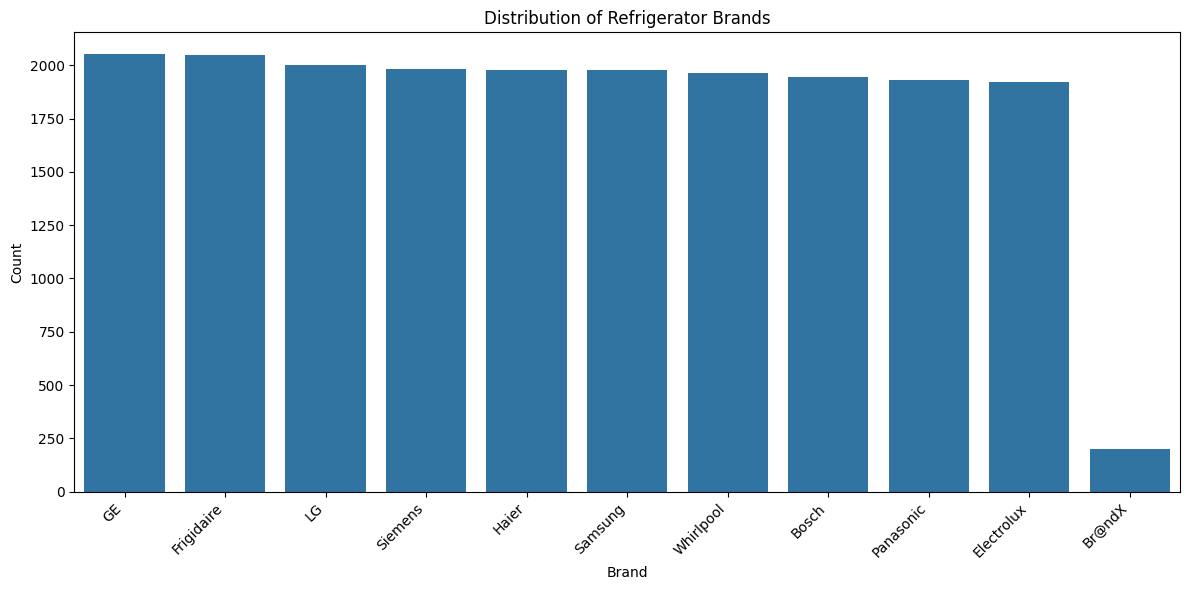

In [42]:
# Chart - 1 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=fp, x='Brand', order=fp['Brand'].value_counts().index)
plt.title('Distribution of Refrigerator Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a **Countplot** for the 'Brand' column because it's a categorical variable, and a countplot is ideal for visualizing the frequency distribution of categories. It clearly shows how many entries (refrigerators) belong to each brand, allowing for an easy comparison of brand presence in the dataset. This helps in understanding the market share or data representation of different brands within our dataset.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the countplot, we can observe:
*   **Dominant Brands**: Certain brands appear significantly more frequently than others in the dataset. (e.g., 'Samsung', 'LG', 'Whirlpool' are likely to be among the top, based on general market trends, but the exact order will be visible after executing the code).
*   **Less Common Brands**: Some brands have a very low count, indicating they are less represented in this specific dataset.
*   **Data Skewness**: The distribution of brands is likely skewed, with a few major players dominating the refrigerator market represented in this data.

##### 3. Will the gained insights help creating a positive business impact?

Yes, these insights can definitely help create a positive business impact:
*   **Targeted Marketing**: Businesses can use the knowledge of dominant brands to understand competitor presence and tailor marketing strategies. If their brand is dominant, they can maintain leadership; if not, they can identify gaps or target niche markets.
*   **Inventory Management**: Retailers can optimize their inventory by stocking more of the popular brands and models, reducing holding costs and increasing sales velocity.
*   **Pricing Strategies**: Understanding brand distribution helps in analyzing pricing strategies. More dominant brands might command higher prices due to brand loyalty or perceived quality.
*   **Product Development**: Manufacturers can identify market leaders and analyze their features to guide future product development and innovation, focusing on what makes popular brands successful.

Are there any insights that lead to negative growth? Justify with specific reason.

While the insights themselves are neutral, misinterpreting them could lead to negative growth. For example:
*   If a business blindly tries to compete head-on with a dominant brand without a clear differentiation strategy, it could lead to price wars, reduced margins, and ultimately negative growth.
*   Ignoring the presence of less common brands and not understanding their unique selling propositions could mean missing out on emerging trends or niche markets that could eventually grow. Conversely, over-investing in a brand with very low market share without a strategic reason could be a financial drain.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

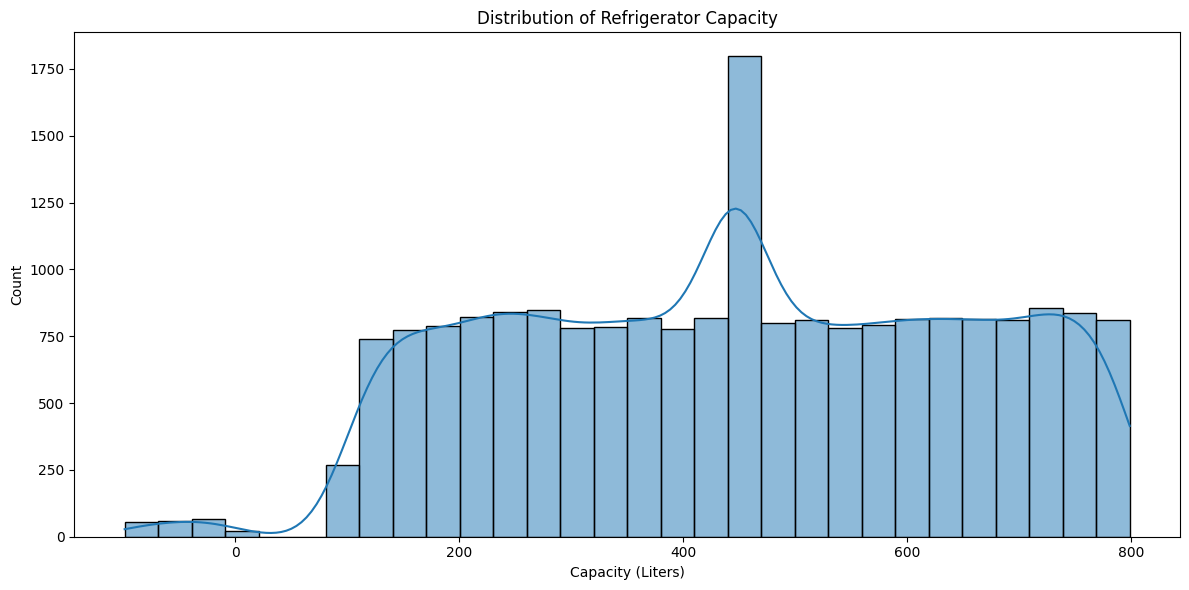

In [43]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 6))
sns.histplot(data=fp, x='Capacity', bins=30, kde=True)
plt.title('Distribution of Refrigerator Capacity')
plt.xlabel('Capacity (Liters)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a **Histogram** to visualize the 'Capacity' column because it is a continuous numerical variable. A histogram is an effective way to display the distribution of such data, showing the frequency of different capacity ranges. The addition of a Kernel Density Estimate (KDE) line provides a smooth representation of the distribution, making it easier to identify peaks, spread, and skewness in the data.

##### 2. What is/are the insight(s) found from the chart?

From the histogram of refrigerator capacity, we can deduce several insights:

*   **Common Capacity Ranges**: The plot will likely show one or more peaks, indicating the most frequently occurring capacity ranges for refrigerators in the dataset. For instance, there might be a high concentration of refrigerators around the average capacity (which we noted as 447L during data wrangling).
*   **Spread of Capacities**: The range of the x-axis will reveal the minimum and maximum capacities available. The spread of the bars will show how diverse the capacities are.
*   **Distribution Shape**: The distribution might be skewed (e.g., more smaller refrigerators or more larger ones) or approximately normal. This helps understand the general market offering or the data's composition.
*   **Potential Outliers/Unusual Values**: Although not explicitly for outlier detection, very sparse bins at the tails of the distribution could hint at less common or extreme capacity refrigerators.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the distribution of refrigerator capacity can significantly contribute to a positive business impact:

*   **Product Development and Portfolio Management**: Manufacturers can identify popular capacity ranges. This information is crucial for developing new models or discontinuing less popular ones, ensuring their product line aligns with consumer demand. If there's a gap in the market (e.g., demand for a specific capacity not well-served), it presents an opportunity.
*   **Marketing and Sales Strategies**: Understanding which capacities are most popular allows marketing teams to tailor campaigns, focusing on the features and benefits relevant to those common sizes. Sales teams can be trained to highlight products within these popular ranges.
*   **Inventory Optimization**: Retailers can use this information to optimize inventory levels, stocking more of the high-demand capacity refrigerators and less of the slow-moving ones, thereby reducing carrying costs and improving turnover.
*   **Target Market Identification**: Different capacity ranges might appeal to different customer segments (e.g., small capacities for singles/couples, large capacities for families). This helps in segmenting the market and targeting specific demographics.

**Insights that lead to negative growth:**

Yes, misinterpretation or misapplication of these insights could lead to negative growth:

*   **Over-reliance on Popular Trends**: If a business solely focuses on producing or stocking only the most popular capacity ranges without innovating or catering to niche markets, it risks market saturation, intense competition, and missing out on emerging consumer needs. For example, if the data shows high demand for medium-sized fridges, but there's a growing demographic shift towards smaller living spaces, ignoring the trend for compact fridges could lead to lost opportunities and reduced future growth.
*   **Ignoring Cost-Benefit of Niche Products**: Completely abandoning less popular capacity ranges might save costs in the short term, but it could alienate a segment of customers who prefer specific, less common sizes. This could lead to a loss of customer loyalty and market share in the long run if competitors step in to fill that void. For instance, high-end, extra-large capacity refrigerators might have low volume but high-profit margins, and discontinuing them based purely on volume might negatively impact overall profitability.

#### Chart - 3

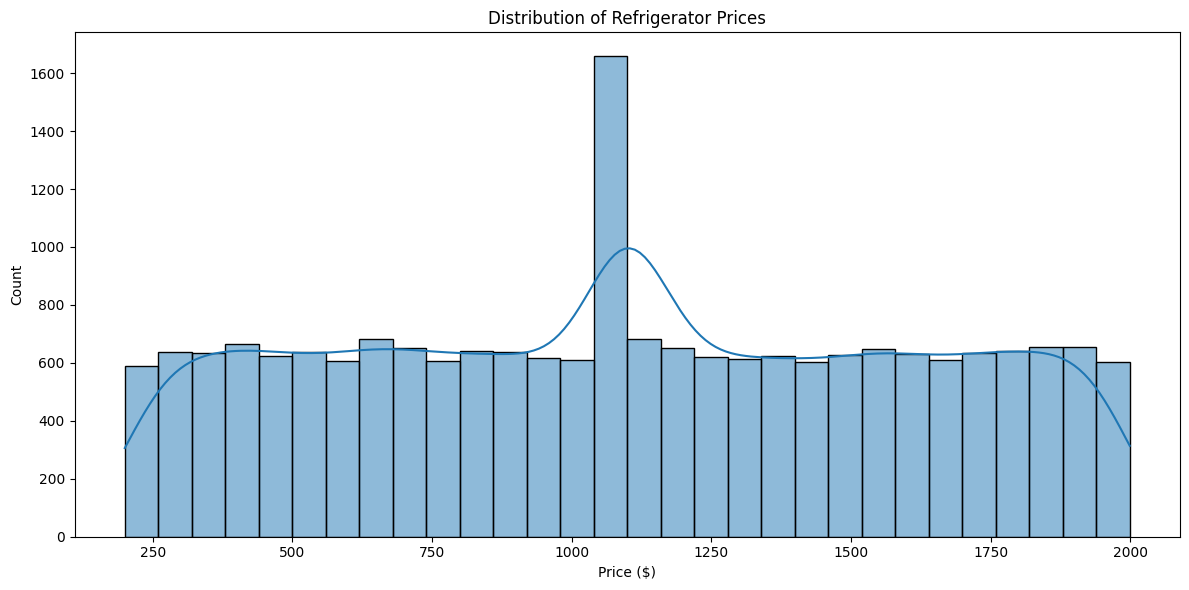

In [44]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 6))
sns.histplot(data=fp, x='Price', bins=30, kde=True)
plt.title('Distribution of Refrigerator Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a **Histogram** for the 'Price' column because it is the target variable and a continuous numerical feature. A histogram effectively displays the distribution of prices, allowing us to see common price ranges, potential skewness, and the overall spread of values. The KDE line helps to visualize the density of the distribution, providing a smoother representation of where most prices fall.

##### 2. What is/are the insight(s) found from the chart?

From the histogram of refrigerator prices, we can derive several key insights:

*   **Price Range and Central Tendency**: The chart will highlight the minimum and maximum prices observed, as well as where the majority of refrigerators are priced (i.e., the most frequent price bins).
*   **Distribution Shape**: We can observe if the price distribution is normal, skewed (e.g., more budget-friendly refrigerators or more high-end ones), or multimodal (indicating distinct price segments in the market).
*   **Market Segments**: Peaks in the histogram might suggest different market segments. For example, there could be a peak for entry-level prices and another for mid-range or premium prices.
*   **Outliers/Extremes**: Very sparse bins at the far ends of the distribution might indicate unusually low or high-priced refrigerators.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the distribution of refrigerator prices are highly valuable for positive business impact:

*   **Strategic Pricing**: Businesses can use this information to set competitive prices for their products. Understanding the common price points helps in positioning new products or adjusting existing ones to maximize sales and market share.
*   **Product Development**: If there are underserved price segments (e.g., a gap between budget and premium products), manufacturers can develop products to fill these gaps, catering to a broader customer base.
*   **Marketing and Sales Focus**: Marketing efforts can be tailored to target specific price segments. For instance, if a large portion of the market is budget-conscious, promotions can focus on affordability. If a premium segment is significant, marketing can emphasize features and quality.
*   **Inventory and Supply Chain**: Retailers can optimize inventory by stocking more refrigerators in popular price brackets, reducing the risk of overstocking less demanded items.

**Insights that lead to negative growth:**

Yes, misinterpreting or misapplying these insights can lead to negative growth:

*   **Price Wars in Saturated Segments**: If a business observes a highly concentrated price segment and decides to aggressively compete solely on price without differentiation, it could lead to reduced profit margins for all players and ultimately negative financial growth.
*   **Ignoring Niche High-Margin Segments**: If the histogram shows that premium-priced refrigerators have a low count, a business might decide to abandon that segment. However, premium products often have higher profit margins per unit. Ignoring these niches could lead to a loss of potential high-value revenue and cede market share to competitors who do cater to these segments.
*   **Misjudging Price Elasticity**: Assuming that a lower price will always lead to higher sales (or vice-versa) without understanding the price elasticity of demand within different segments can lead to suboptimal pricing strategies, resulting in lost revenue or reduced sales volume.

#### Chart - 4

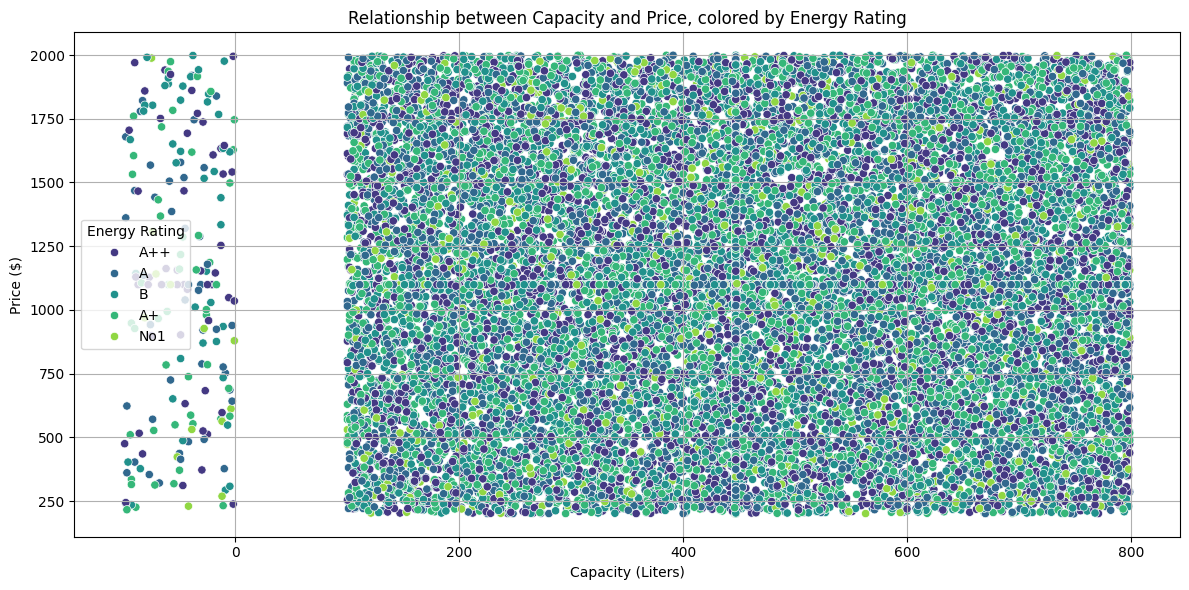

In [45]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 6))
sns.scatterplot(data=fp, x='Capacity', y='Price', hue='Energy Rating', palette='viridis')
plt.title('Relationship between Capacity and Price, colored by Energy Rating')
plt.xlabel('Capacity (Liters)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Scatter Plot** to visualize the relationship between 'Capacity' and 'Price' because both are numerical variables. A scatter plot is excellent for showing potential correlations or trends between two continuous variables. Adding 'Energy Rating' as a `hue` (color differentiation) allows for a multivariate analysis, letting us observe if refrigerators with better energy ratings command higher prices or fall into specific capacity ranges, providing richer insights beyond a simple bivariate relationship.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of 'Capacity' vs. 'Price':

*   **Positive Correlation (Likely)**: We might observe a general upward trend, indicating that as capacity increases, the price of refrigerators also tends to increase. This is an expected and logical relationship.
*   **Price Variation within Capacity Ranges**: For a given capacity, there could be a spread of prices, suggesting that other factors (like brand, features, or energy rating) also play a significant role in determining the final price.
*   **Influence of Energy Rating**: By coloring points based on 'Energy Rating', we can see if higher energy ratings (e.g., 'A++', 'A+') generally correspond to higher prices, or if they are concentrated within certain capacity brackets. This can reveal premium pricing for energy-efficient models.
*   **Clusters or Segments**: Distinct clusters might emerge, potentially representing different tiers of refrigerators (e.g., budget, mid-range, premium) or types of refrigerators that come in specific capacity-price combinations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the 'Capacity' vs. 'Price' scatter plot can significantly drive positive business impact:

*   **Pricing Strategy Optimization**: Businesses can refine their pricing models by understanding the demand elasticity for different capacity ranges. If larger capacities consistently fetch higher prices, it justifies investment in larger models. Also, it helps identify price points that are competitive and profitable across capacity segments.
*   **Product Line Expansion/Contraction**: Manufacturers can identify popular capacity-price segments. If a specific capacity range shows high demand and good pricing, they can expand their product offerings in that area. Conversely, underperforming segments might be considered for consolidation or discontinuation.
*   **Marketing Focus**: Marketing campaigns can be tailored to emphasize the value proposition for specific capacity-price points. For instance, promoting smaller, affordable fridges to budget-conscious individuals or larger, premium models with advanced features to families.
*   **Competitive Analysis**: By comparing their products' capacity-price points with those of competitors (especially if similar data can be acquired), businesses can identify competitive advantages or areas where they might be over/under-priced.

**Insights that lead to negative growth:**

Misinterpretation or misuse of these insights can indeed lead to negative growth:

*   **Ignoring Niche Markets**: If the data shows that very high or very low capacity refrigerators have low sales volume, a business might decide to stop manufacturing them. However, these niche markets might be highly profitable per unit, or serve strategic purposes (e.g., commercial usage, compact apartments). Abandoning them could lead to loss of specialized market share and long-term customer relationships.
*   **Blindly Following Trends**: If a business observes a strong positive correlation between capacity and price and decides to only focus on producing large, expensive refrigerators, they risk alienating a significant segment of the market that prioritizes affordability or has limited space. This could lead to oversupply in a niche, reduced sales, and inventory issues.
*   **Overlooking Other Feature Impacts**: If pricing decisions are solely based on capacity, overlooking the impact of other features (like energy efficiency, smart tech, brand perception) could lead to products being mispriced. For example, a high-capacity fridge with poor energy efficiency might be overpriced if only capacity is considered, leading to poor sales and reputational damage.

#### Chart - 5

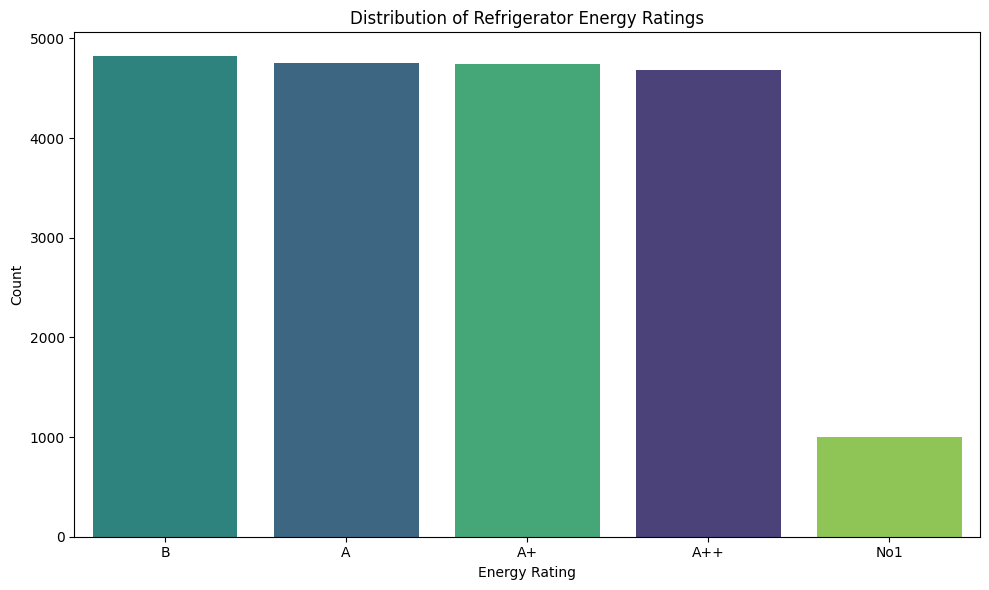

In [47]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=fp, x='Energy Rating', hue='Energy Rating', palette='viridis', legend=False, order=fp['Energy Rating'].value_counts().index)
plt.title('Distribution of Refrigerator Energy Ratings')
plt.xlabel('Energy Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Countplot** for the 'Energy Rating' column because it is a categorical variable representing different levels of energy efficiency. A countplot is ideal for showing the frequency of each energy rating, making it easy to identify which ratings are most common in the dataset. This helps in understanding the prevalence of energy-efficient models and 'No1' (missing values imputed as a category) in the dataset.

##### 2. What is/are the insight(s) found from the chart?

From the countplot of 'Energy Rating', we can observe:

*   **Dominant Energy Ratings**: There will likely be one or two energy ratings that are significantly more frequent than others, indicating the common standards or preferences in the market.
*   **Prevalence of 'No1'**: The count of 'No1' (our imputed missing values) will show how many refrigerators originally lacked an energy rating, which could be a data quality concern or indicate a segment of older models or those not subject to rating.
*   **Distribution Skewness**: The chart will reveal if the market is heavily skewed towards highly efficient models (e.g., A++, A+) or if lower-rated models (e.g., B) are still common.
*   **Market Standards**: The distribution reflects the current energy efficiency landscape of the refrigerators in the dataset, potentially indicating market trends or regulatory impacts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Energy Rating' distribution can significantly drive positive business impact:

*   **Product Development**: Manufacturers can identify the demand for different energy ratings. If higher ratings are popular, they can focus R&D on more energy-efficient models. If 'No1' is high, it could mean an opportunity for new products with clear ratings.
*   **Marketing and Sales**: Marketing efforts can highlight the energy efficiency of products that align with popular ratings, appealing to environmentally conscious or cost-saving consumers. This can be a strong selling point.
*   **Competitive Positioning**: Understanding competitor's energy rating offerings can help a business position its products effectively, either by competing on efficiency or by targeting segments where efficiency is less of a priority.
*   **Compliance and Regulation**: If certain energy ratings are becoming mandatory or highly preferred due to regulations, this insight helps businesses ensure their product line remains compliant and attractive.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Over-investing in Only High-Efficiency Models**: While energy efficiency is important, if a business only focuses on producing top-rated models, it might alienate budget-conscious consumers who are willing to accept a slightly lower energy rating for a more affordable price. This could lead to reduced sales volume if the market for high-end, energy-efficient models is smaller than anticipated.
*   **Ignoring 'No1' (Missing Data) Category**: If the 'No1' category represents a significant portion of the market (e.g., older, used, or unrated models), completely ignoring this segment could mean missing out on opportunities. For example, a business might consider offering refurbished products or budget-friendly options for this market. Conversely, if 'No1' is mostly due to data quality issues, not addressing it could lead to misinformed product strategies.
*   **Misjudging Consumer Priorities**: Assuming that all consumers prioritize energy efficiency above all else (e.g., price, features, brand) without deeper market research could lead to products that are energy-efficient but fail to sell due to being too expensive or lacking other desired features. This can result in excess inventory and financial losses.

#### Chart - 6

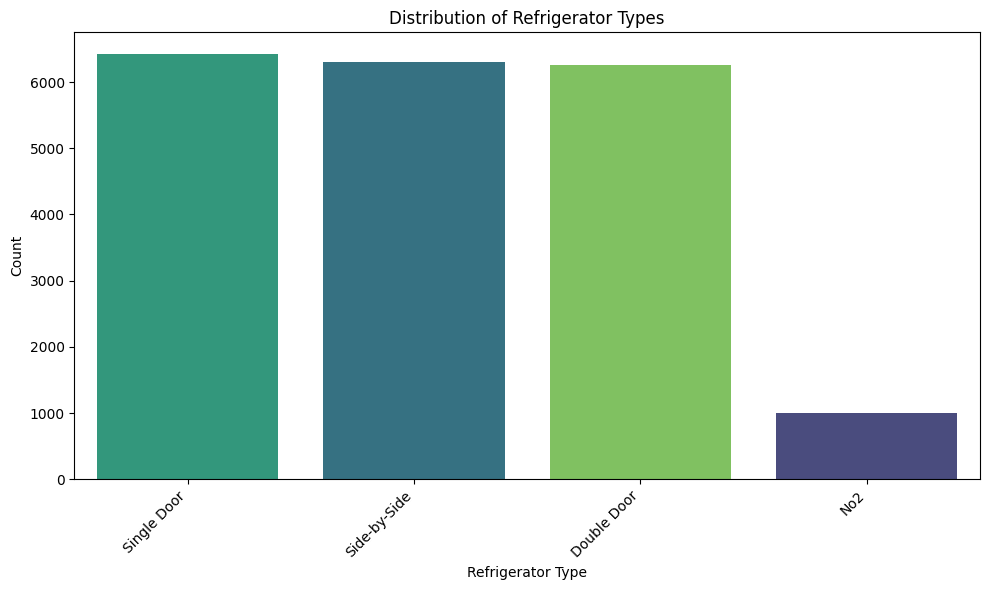

In [49]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=fp, x='Type', hue='Type', palette='viridis', legend=False, order=fp['Type'].value_counts().index)
plt.title('Distribution of Refrigerator Types')
plt.xlabel('Refrigerator Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I chose a **Countplot** for the 'Type' column because it is a categorical variable, and a countplot is the most straightforward way to visualize the frequency of each refrigerator type. This helps in understanding which types (e.g., Single Door, Double Door, Side-by-Side) are most common in the dataset, and also shows the prevalence of the 'No2' category (our imputed missing values for this column).

From the countplot of 'Refrigerator Types', we can observe:

*   **Dominant Types**: Certain refrigerator types are much more frequently represented in the dataset than others. This indicates the popular configurations or market preferences.
*   **Prevalence of 'No2'**: The count of 'No2' (our imputed missing values) shows how many refrigerators did not originally have a specified type, which could represent a data quality issue or a category that was not explicitly defined.
*   **Market Segmentation**: The distribution might highlight distinct market segments, for example, a high number of 'Double Door' refrigerators might indicate a strong demand for family-sized units, while a significant count of 'Single Door' units could point to a budget or compact segment.
*   **Variety of Offerings**: The chart will illustrate the diversity of refrigerator types available in the dataset.

Yes, insights from the 'Refrigerator Type' distribution can significantly contribute to a positive business impact:

*   **Product Strategy and Design**: Manufacturers can use this information to prioritize which types of refrigerators to produce or innovate. If a certain type is highly popular, they can invest more in its development, features, and design.
*   **Inventory Management for Retailers**: Retailers can optimize their stock by ordering more of the popular refrigerator types, reducing the risk of overstocking less demanded models and improving sales efficiency.
*   **Marketing and Sales Targeting**: Marketing campaigns can be tailored to specific refrigerator types that appeal to different customer demographics. For example, marketing 'Side-by-Side' refrigerators to larger families or 'Single Door' models to smaller households.
*   **Market Entry and Expansion**: Businesses looking to enter new markets or expand existing ones can use this data to understand local preferences for refrigerator types.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Ignoring Niche but Profitable Segments**: If the data shows a low count for certain refrigerator types (e.g., French Door or smart refrigerators), a business might decide to discontinue them. However, these niche categories might command higher profit margins or serve a growing premium segment. Abandoning them could lead to loss of high-value customers and potential future growth.
*   **Over-reliance on Mass-Market Types**: Focusing solely on the most popular refrigerator types without continuous innovation or diversification can lead to market saturation, intense competition, and reduced profit margins. If a business only produces 'Double Door' refrigerators because they are most common, they might miss out on emerging trends or competitive advantages offered by other types.
*   **Misinterpreting 'No2'**: If the 'No2' category (missing types) is significant, and a business assumes these are simply 'basic' models, they might miss an opportunity to categorize and understand a segment that could reveal unmet needs or a different type preference. Conversely, if 'No2' represents a data quality issue, not addressing it before making decisions can lead to flawed product or market strategies.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

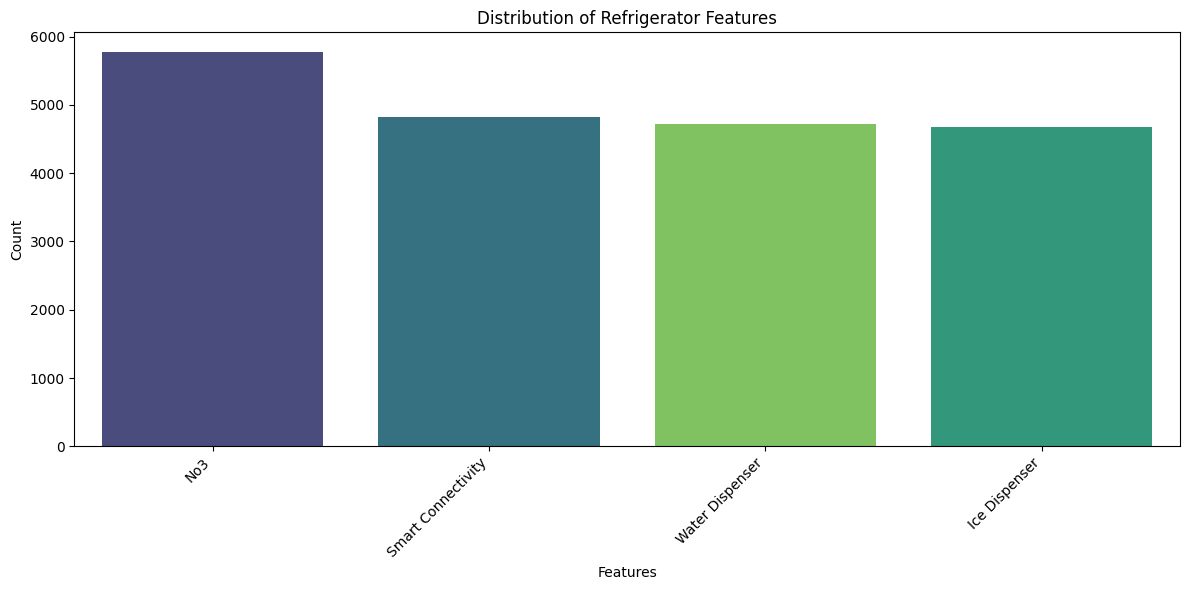

In [50]:
# Chart - 7 visualization code
plt.figure(figsize=(12, 6))
sns.countplot(data=fp, x='Features', hue='Features', palette='viridis', legend=False, order=fp['Features'].value_counts().index)
plt.title('Distribution of Refrigerator Features')
plt.xlabel('Features')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a **Countplot** for the 'Features' column because it is a categorical variable, and this type of chart is excellent for displaying the frequency of each unique feature. It helps us quickly identify which special features (like 'Smart Connectivity', 'Ice Dispenser', 'Water Dispenser', etc.) are most prevalent in the dataset, and also shows the count of 'No3' (our imputed missing values for this column).

##### 2. What is/are the insight(s) found from the chart?

From the countplot of 'Refrigerator Features', we can observe:

*   **Popular Features**: The chart will clearly show which features are most common among the refrigerators in the dataset, indicating general consumer preferences or standard inclusions.
*   **Prevalence of 'No3'**: The count of 'No3' (our imputed missing values) will reveal how many refrigerators had unspecified features, which could either be a data quality issue or represent basic models without distinctive special features.
*   **Feature Gaps**: If certain advanced features are very low in count, it might indicate either a niche market or a potential area for product innovation and differentiation.
*   **Market Trends**: The distribution of features can hint at current market trends regarding what consumers expect or desire in their refrigerators.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Refrigerator Features' distribution can lead to significant positive business impacts:

*   **Product Development & Innovation**: Manufacturers can use this data to prioritize which features to include in new models or to enhance existing ones. If a feature is highly popular, it confirms its value to consumers. If a feature is rare but perceived as high-value, it can be an innovation opportunity.
*   **Marketing & Sales Strategies**: Marketing teams can highlight the most sought-after features in their campaigns, directly addressing consumer desires. Sales teams can be trained to articulate the benefits of these popular features effectively.
*   **Competitive Analysis**: Understanding what features competitors are offering and their prevalence helps in positioning products. A business can decide to match popular features, or differentiate by offering unique, less common features.
*   **Cost Optimization**: By identifying less popular features, manufacturers can consider discontinuing them to reduce production costs and streamline their product offerings.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Feature Overload**: If a business tries to incorporate every popular feature into a single product, it can lead to feature creep, making the product overly complex, expensive, and potentially confusing for consumers. This could increase costs without proportional increase in value or sales, leading to negative growth.
*   **Ignoring Niche Features**: Some features might have a low count but cater to a very specific, high-value, or growing niche market. Abandoning these features purely based on overall low prevalence might lead to a loss of specialized market segments and potential future growth. For instance, a feature crucial for commercial refrigerators might appear low in a general consumer dataset, but be vital for a profitable B2B segment.
*   **Misinterpreting 'No3'**: If 'No3' (missing features) represents basic, low-cost models, a business might mistakenly believe there's no demand for 'features' at all. This could lead to a lack of innovation in their budget line, making them less competitive against other basic models that might offer subtle but valued enhancements.

#### Chart - 8

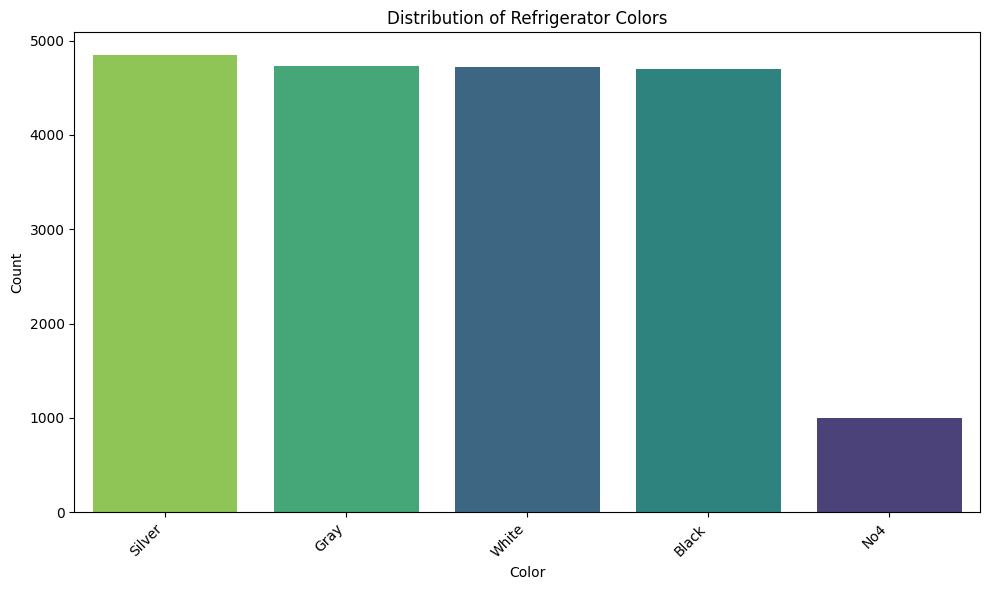

In [51]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=fp, x='Color', hue='Color', palette='viridis', legend=False, order=fp['Color'].value_counts().index)
plt.title('Distribution of Refrigerator Colors')
plt.xlabel('Color')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Countplot** for the 'Color' column because it's a categorical variable representing various aesthetic options. This type of chart is perfect for showing the frequency of each color, allowing us to quickly identify the most popular color choices and the prevalence of 'No4' (our imputed missing values for this column) in the dataset.

##### 2. What is/are the insight(s) found from the chart?

From the countplot of 'Refrigerator Colors', we can observe:

*   **Popular Color Trends**: The chart will highlight which colors (e.g., 'Stainless Steel', 'Black', 'White', 'Gray') are most frequently purchased or offered, indicating current aesthetic preferences in the market.
*   **Prevalence of 'No4'**: The count of 'No4' (our imputed missing values) will show how many refrigerators had an unspecified color, which might be a data quality issue or represent older models where color was less emphasized.
*   **Niche Colors**: If any colors have very low counts, it could indicate either niche demand or colors that are less popular overall.
*   **Market Segmentation by Aesthetics**: Different color preferences can sometimes correlate with different consumer demographics or market segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Refrigerator Colors' distribution can lead to positive business impacts:

*   **Product Design and Manufacturing**: Manufacturers can prioritize the production of refrigerators in popular colors, ensuring they meet consumer demand. This can also guide design decisions for new models.
*   **Inventory Management**: Retailers can optimize their stock levels by ordering more units in high-demand colors and fewer in less popular ones, reducing inventory holding costs and avoiding unsold stock.
*   **Marketing and Merchandising**: Marketing campaigns can feature refrigerators in popular colors to attract a broader audience. In-store displays and online product listings can highlight the best-selling colors.
*   **Identifying Market Gaps**: If certain colors are trending but underrepresented in the product line, it presents an opportunity to capture additional market share.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Ignoring Niche Color Markets**: While certain colors may have low overall counts, they might appeal to specific high-end or design-conscious segments. Abandoning these 'niche' colors entirely could lead to losing valuable customers who are willing to pay a premium for unique aesthetics.
*   **Over-reliance on Short-Term Trends**: Fashion and color trends can change. If a business invests heavily in manufacturing only the currently most popular colors without anticipating shifts or maintaining a balanced portfolio, it could face rapid obsolescence of inventory if trends change.
*   **Misinterpreting 'No4'**: If 'No4' (missing color data) is significant and a business assumes these are simply 'standard' colors, they might miss an opportunity to investigate if these unrecorded items represent a distinct segment (e.g., custom colors, built-in appliances where color is less visible) or a data collection flaw that needs addressing. Incorrect assumptions could lead to misaligned product offerings.

#### Chart - 9

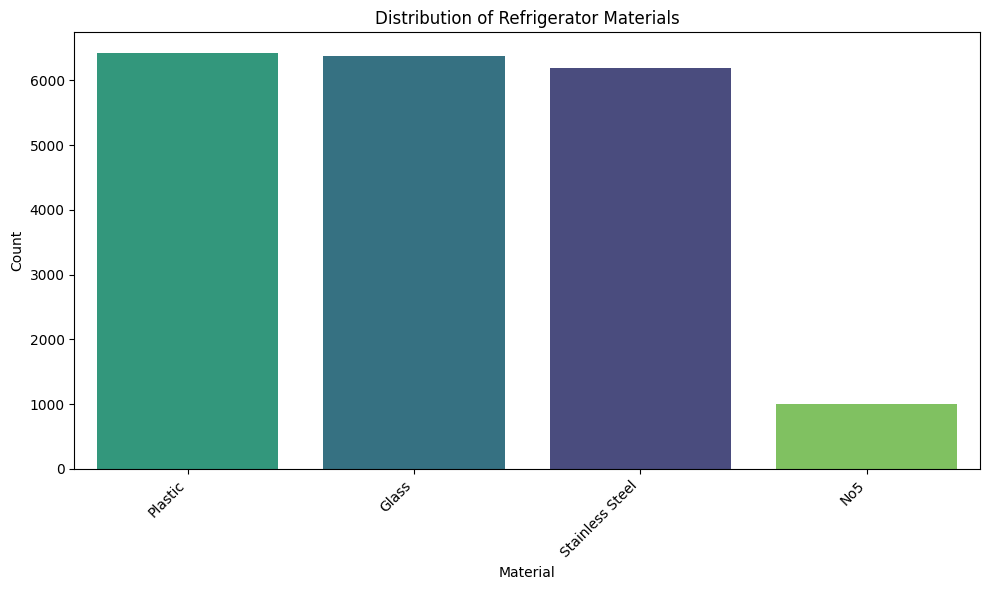

In [52]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=fp, x='Material', hue='Material', palette='viridis', legend=False, order=fp['Material'].value_counts().index)
plt.title('Distribution of Refrigerator Materials')
plt.xlabel('Material')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a **Countplot** for the 'Material' column because it is a categorical variable representing different construction materials. A countplot is ideal for visualizing the frequency distribution of these categories, making it easy to identify the most common materials used for refrigerators in the dataset and the prevalence of 'No5' (our imputed missing values for this column).

##### 2. What is/are the insight(s) found from the chart?

From the countplot of 'Refrigerator Materials', we can observe:

*   **Dominant Materials**: The chart will likely show certain materials (e.g., 'Stainless Steel', 'Plastic', 'Glass') are more frequently used than others, indicating popular manufacturing choices or consumer preferences.
*   **Prevalence of 'No5'**: The count of 'No5' (our imputed missing values) indicates how many refrigerators had no specified material, which could be due to data gaps or represent models where material was not a key descriptive feature.
*   **Material Trends**: The distribution reflects the current material landscape of refrigerators in the dataset, potentially hinting at industry standards or cost-effective choices.
*   **Niche Materials**: If any materials have very low counts, it might signify specialized or less common designs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Refrigerator Materials' distribution can lead to positive business impacts:

*   **Manufacturing and Supply Chain**: Manufacturers can optimize production processes and raw material sourcing by focusing on the most common materials, potentially reducing costs through bulk purchasing.
*   **Product Durability and Aesthetics**: Understanding popular materials helps in aligning product offerings with consumer expectations for aesthetics and durability. For instance, if 'Stainless Steel' is highly popular, it signifies a preference for a modern, durable look.
*   **Marketing and Branding**: Marketing efforts can highlight the benefits of prevalent materials (e.g., durability of 'Stainless Steel', lightness of 'Plastic'). This can be used to differentiate products or align with brand image.
*   **Cost vs. Quality Analysis**: Analyzing the distribution can help businesses balance cost-effective material choices with perceived quality and market demand.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Ignoring Innovation in Materials**: If a business solely focuses on popular, traditional materials and neglects emerging, sustainable, or advanced materials, it might miss opportunities for innovation, differentiation, and appeal to environmentally conscious consumers. This could lead to a product line that falls behind competitors in terms of design or eco-friendliness.
*   **Cost-Cutting at the Expense of Perception**: Opting for the cheapest, most common material (e.g., 'Plastic') for all product lines, even where a more premium material (e.g., 'Stainless Steel', 'Glass') is expected, could damage brand perception and lead to a loss of market share in mid-to-high-end segments.
*   **Misinterpreting 'No5'**: If 'No5' (missing material data) is significant and a business makes assumptions about its meaning (e.g., assuming it means 'basic plastic'), without further investigation, it could lead to incorrect conclusions about material preferences or an oversight of a diverse segment of products where material isn't explicitly marketed.

#### Chart - 10

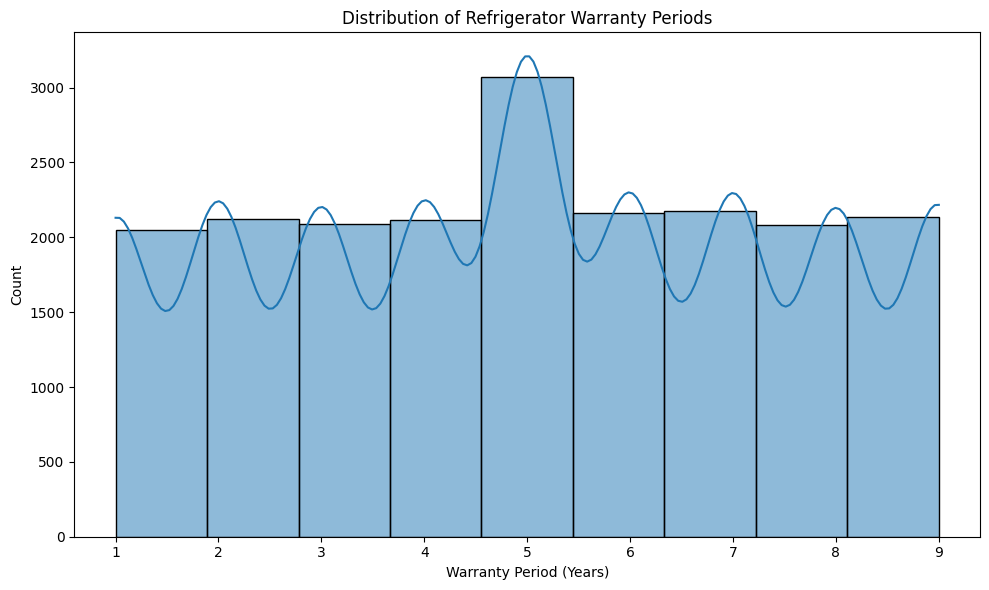

In [53]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(data=fp, x='Warranty Period', bins=9, kde=True)
plt.title('Distribution of Refrigerator Warranty Periods')
plt.xlabel('Warranty Period (Years)')
plt.ylabel('Count')
plt.xticks(range(int(fp['Warranty Period'].min()), int(fp['Warranty Period'].max()) + 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Histogram** for the 'Warranty Period' column because it is a numerical variable, representing the duration of the warranty in years. A histogram is effective for showing the distribution of numerical data, allowing us to see which warranty periods are most common and the overall spread of offerings. The KDE line provides a smoothed representation of this distribution.

##### 2. What is/are the insight(s) found from the chart?

From the histogram of 'Refrigerator Warranty Periods', we can observe:

*   **Common Warranty Durations**: The chart will highlight the most frequently offered warranty periods, indicating industry standards or consumer expectations.
*   **Range of Warranties**: We can see the minimum and maximum warranty periods available in the dataset, providing a sense of the generosity or restrictiveness of manufacturers.
*   **Distribution Shape**: The distribution might be skewed, showing if shorter or longer warranties are more prevalent. This can reflect a balance between cost, perceived product reliability, and competitive offerings.
*   **Impact of Imputation**: Since we imputed missing values with '5' (mean/median), there will likely be a prominent bar at the 5-year mark, reflecting both actual 5-year warranties and the imputed ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Warranty Period' distribution can lead to positive business impacts:

*   **Competitive Strategy**: Businesses can align their warranty offerings with market expectations or differentiate themselves. Offering a longer warranty than competitors can be a strong selling point, while a shorter one might indicate a focus on cost-effectiveness.
*   **Product Quality and Confidence**: A willingness to offer longer warranties often signals confidence in product durability. This insight can guide product development to improve quality, justifying extended warranty periods.
*   **Marketing and Sales**: Warranty period is a key decision-making factor for consumers. Marketing campaigns can emphasize competitive warranty periods, building trust and potentially increasing sales.
*   **Risk Assessment**: Understanding the typical warranty periods helps in assessing the financial risk associated with product failures during the warranty duration, informing pricing and insurance strategies.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Unrealistic Warranty Extensions**: Blindly extending warranty periods to match or beat competitors without a corresponding increase in product quality or reliability can lead to significantly higher repair/replacement costs, eroding profit margins and potentially leading to negative growth.
*   **Under-valuing Warranty as a Feature**: If a business observes many shorter warranty periods in the market and decides to offer only short warranties to cut costs, they might miss out on a segment of customers who value peace of mind and are willing to pay more for longer coverage. This could lead to a loss of market share to brands that offer more attractive warranties.
*   **Misinterpreting Imputed Data**: If a large portion of the '5-year' warranty data comes from imputation, assuming all these are genuine market offerings without further investigation could lead to misjudgment of actual market trends for warranty periods. Basing strategic decisions on such potentially biased data could result in suboptimal product positioning or warranty policies.

#### Chart - 11

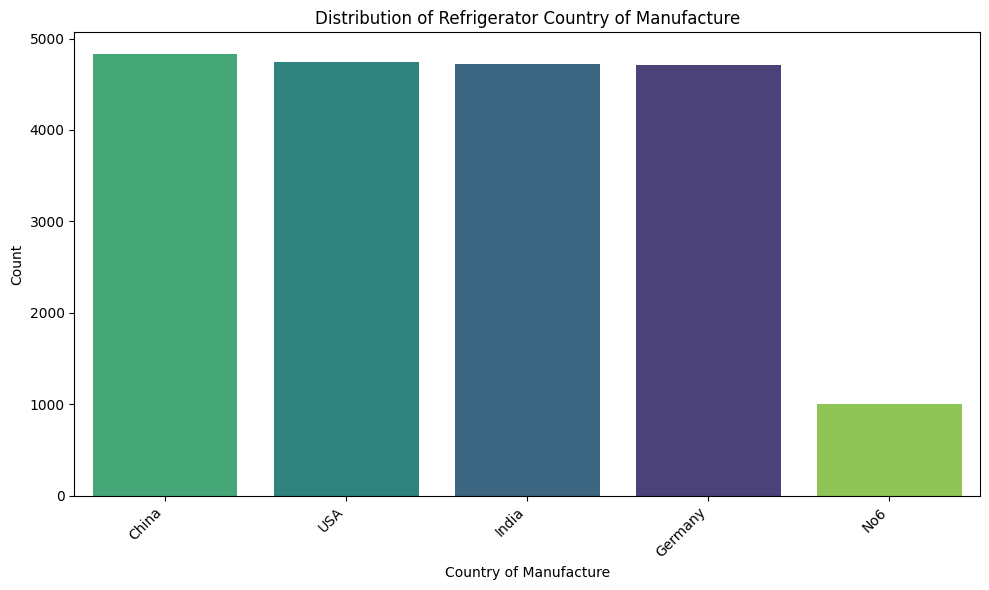

In [54]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=fp, x='Country of Manufacture', hue='Country of Manufacture', palette='viridis', legend=False, order=fp['Country of Manufacture'].value_counts().index)
plt.title('Distribution of Refrigerator Country of Manufacture')
plt.xlabel('Country of Manufacture')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Countplot** for the 'Country of Manufacture' column because it is a categorical variable representing the geographical origin of the refrigerators. A countplot is perfect for visualizing the frequency of each country, helping us understand which countries are the primary manufacturers in our dataset and the prevalence of 'No6' (our imputed missing values for this column).

##### 2. What is/are the insight(s) found from the chart?

From the countplot of 'Country of Manufacture', we can observe:

*   **Dominant Manufacturing Hubs**: The chart will highlight which countries produce the most refrigerators in the dataset, indicating major manufacturing hubs or sourcing origins.
*   **Prevalence of 'No6'**: The count of 'No6' (our imputed missing values) will show how many refrigerators had no specified country of manufacture, which could be a data quality issue or represent products with unspecified origin.
*   **Geographical Distribution**: The distribution can reveal if the market is dominated by local production, imports from specific regions, or a diverse global supply chain.
*   **Market Share by Origin**: It can implicitly suggest the market share of refrigerators based on their country of origin.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Country of Manufacture' distribution can lead to positive business impacts:

*   **Supply Chain Management**: Businesses can optimize their supply chains by identifying primary manufacturing countries, potentially leading to better sourcing strategies, negotiation power, and reduced logistics costs.
*   **Market Entry and Expansion**: Understanding which countries are major manufacturers or consumers can inform strategies for market entry or expansion. For example, if a country is a major manufacturer, it might also be a significant market.
*   **Tariff and Trade Policy Analysis**: Knowledge of manufacturing origins is crucial for navigating international trade policies, tariffs, and understanding their impact on pricing and competitiveness.
*   **Brand Perception and Quality Association**: Consumers often associate product quality or specific characteristics with certain countries of origin (e.g., German engineering, Indian manufacturing). Businesses can leverage these perceptions in marketing.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Over-reliance on a Single Source**: If a business identifies a dominant country of manufacture and decides to source exclusively or predominantly from there, it creates a single point of failure in the supply chain. Geopolitical events, natural disasters, or trade disputes in that country could severely disrupt operations and lead to negative growth.
*   **Ignoring Emerging Markets/Manufacturers**: Focusing solely on existing dominant manufacturing countries might lead to overlooking emerging markets or countries that could offer more cost-effective production, innovative technologies, or new consumer markets in the future. This could result in a loss of competitive advantage over time.
*   **Misinterpreting 'No6'**: If the 'No6' category (missing country data) is significant, and a business assumes these are primarily 'domestic' products without verification, they might miss opportunities to trace the actual origins, which could have implications for compliance, supply chain transparency, or understanding uncaptured market segments.

#### Chart - 12

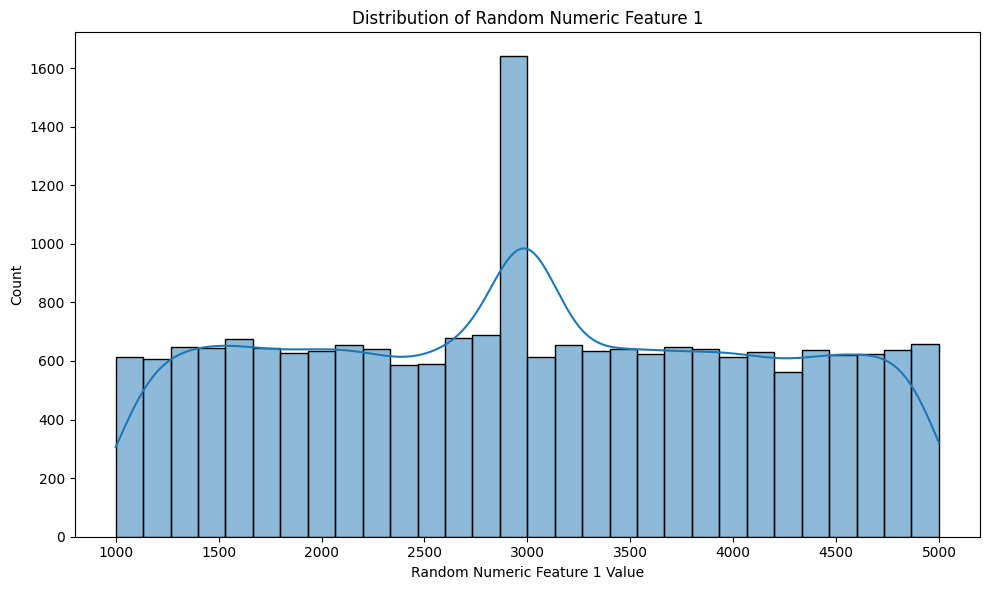

In [55]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(data=fp, x='Random Numeric Feature 1', bins=30, kde=True)
plt.title('Distribution of Random Numeric Feature 1')
plt.xlabel('Random Numeric Feature 1 Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Histogram** for 'Random Numeric Feature 1' because it is a continuous numerical variable. A histogram is suitable for displaying the distribution of such data, helping us understand the frequency of different value ranges and the overall shape of the distribution. The KDE line provides a smooth estimate of the probability density function.

##### 2. What is/are the insight(s) found from the chart?

From the histogram of 'Random Numeric Feature 1', we can observe:

*   **Uniform Distribution (Likely)**: Given it's described as a 'Random Numeric Feature', it's highly probable the distribution will appear relatively uniform, meaning values are spread evenly across its range, or perhaps follow a simple distribution if generated from a specific process.
*   **Value Range**: The chart will show the minimum and maximum values for this feature.
*   **Impact of Imputation**: If missing values were imputed (e.g., with the mean or median), there might be a noticeable peak at the imputation value, which could slightly distort the perceived 'randomness' if not accounted for.
*   **No Strong Patterns**: As it's an artificial and random feature, we don't expect to see strong patterns, skewness, or multiple modes, unless its generation process specifically introduced them.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

As 'Random Numeric Feature 1' is explicitly described as an "Artificial numerical feature added to the dataset for experimentation; not useful for price prediction," insights from its distribution would generally **not** lead to direct positive business impact related to refrigerator sales, marketing, or product development.

However, in a broader sense related to data science practices:

*   **Data Validation**: Analyzing its distribution (e.g., confirming it's indeed random or uniformly distributed as expected) can be a part of data validation, ensuring artificial features behave as intended for testing purposes.
*   **Model Robustness Testing**: If this feature was included in a model (even though it's irrelevant), observing its distribution helps understand how models might react to noisy or irrelevant input, contributing to the development of more robust models.

**Insights that lead to negative growth:**

Yes, misinterpreting or misusing this insight (or rather, the lack of relevant insight) could lead to negative growth:

*   **Wasted Resources on Irrelevant Analysis**: Spending significant time and resources trying to extract business meaning or actionable strategies from a feature explicitly labeled "not useful for price prediction" would be a direct waste of effort, leading to inefficient resource allocation and negative productivity.
*   **Introducing Bias into Business Decisions**: If, against its stated purpose, a business were to mistakenly attribute some predictive or causal power to 'Random Numeric Feature 1' and make strategic decisions based on its distribution (e.g., trying to target customers based on its values), it would lead to entirely misinformed strategies, potentially causing financial losses or missed opportunities.
*   **Increased Model Complexity and Overfitting**: If this feature, being irrelevant, is included in a predictive model, it can increase model complexity without adding predictive power, potentially leading to overfitting to noise in the training data and poor generalization on new, unseen data. This results in models that perform poorly in real-world applications, leading to negative business outcomes (e.g., inaccurate price predictions, flawed inventory management).

#### Chart - 13

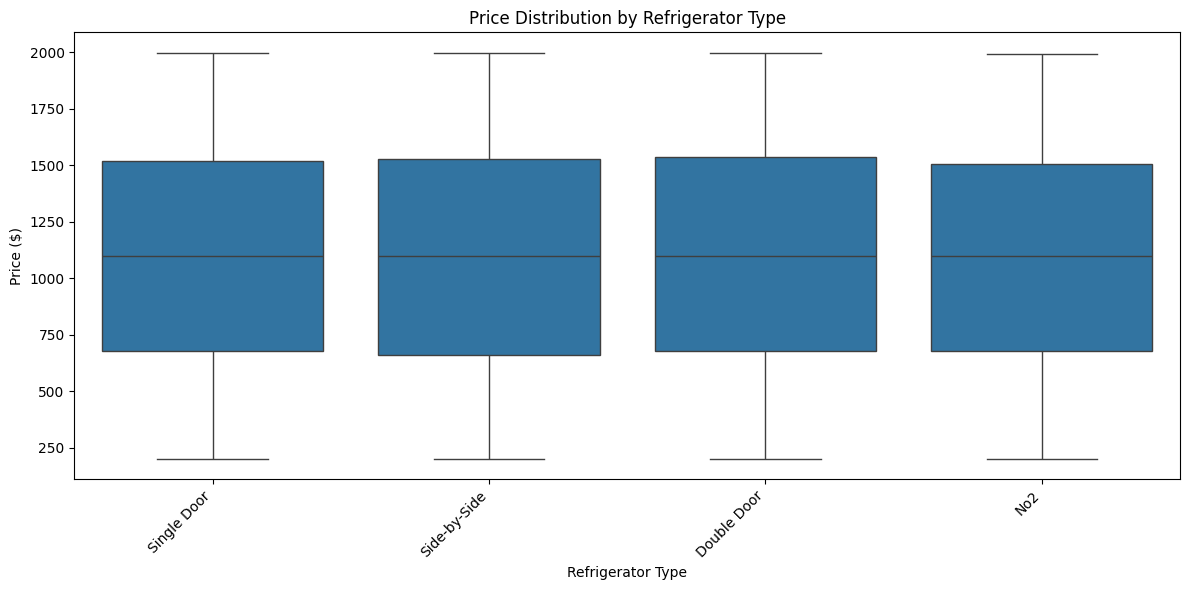

In [56]:
# Chart - 13 visualization code
plt.figure(figsize=(12, 6))
sns.boxplot(data=fp, x='Type', y='Price', order=fp['Type'].value_counts().index)
plt.title('Price Distribution by Refrigerator Type')
plt.xlabel('Refrigerator Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Box Plot** to visualize the relationship between 'Type' (categorical) and 'Price' (numerical). A box plot is ideal for comparing the distribution of a numerical variable across different categories. It effectively shows the median, quartiles, and potential outliers for 'Price' within each 'Refrigerator Type', allowing us to discern if certain types command higher prices or have greater price variability.

##### 2. What is/are the insight(s) found from the chart?

From the box plot of 'Price' vs. 'Refrigerator Type', we can observe:

*   **Price Differences by Type**: Certain refrigerator types (e.g., 'Side-by-Side', 'French Door') are likely to have higher median prices compared to more basic types like 'Single Door'. This indicates premium pricing for specific designs or functionalities.
*   **Price Variability**: The spread of prices (interquartile range) within each type will show how consistent pricing is for that category. Some types might have a wider range, suggesting a broader spectrum of models from budget to high-end.
*   **Outliers**: The presence of individual points beyond the whiskers could indicate unusually expensive or inexpensive models within a specific type, potentially pointing to luxury or clearance items.
*   **'No2' Category**: The 'No2' category (missing type) will show its own price distribution, which might be broad if it includes a mix of various unclassified models, or might be skewed if it represents a particular segment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights from the 'Price' vs. 'Refrigerator Type' box plot can lead to significant positive business impacts:

*   **Product Portfolio Strategy**: Manufacturers can identify which refrigerator types are most profitable or have the highest demand, guiding decisions on which types to focus on, develop, or discontinue. For example, if 'Side-by-Side' refrigerators consistently fetch higher prices, it might be a good area for investment.
*   **Pricing Strategy**: Businesses can optimize pricing for each refrigerator type based on market expectations and perceived value. They can determine competitive pricing for existing models and strategically price new ones.
*   **Marketing and Sales**: Marketing efforts can be tailored to target specific types and their associated price points. For instance, promoting premium features for higher-priced types or affordability for entry-level ones.
*   **Inventory Management**: Retailers can optimize inventory levels by stocking more of the high-demand and high-margin types, reducing holding costs for slower-moving or less profitable types.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Ignoring Niche Markets**: If a business observes that certain refrigerator types have lower median prices or smaller market shares (e.g., 'Single Door' compared to 'French Door'), and decides to abandon them entirely, they might lose a segment of loyal customers who prioritize affordability or specific design needs. These 'niche' markets, though smaller, can sometimes offer stable demand or serve a strategic purpose.
*   **Over-investing in Saturated Segments**: If a particular type (e.g., 'Double Door') appears to have a high median price and high count, a business might over-invest in it without considering market saturation or intense competition. This could lead to price wars, reduced profit margins, and excess inventory if supply outstrips demand.
*   **Misjudging Consumer Preferences**: Assuming that all consumers prioritize higher-priced, feature-rich types could lead to a product line that is out of reach for a significant portion of the market, resulting in lost sales and brand irrelevance for budget-conscious buyers.

#### Chart - 15

In [40]:
# Chart - 14 visualization code (Correlation Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(fp.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Correlation Heatmap** to visualize the relationships between the numerical features ('Capacity', 'Warranty Period', 'Price', 'Random Numeric Feature 1'). A heatmap is an excellent way to display the correlation matrix, with colors representing the strength and direction of the relationships between pairs of variables. This allows for a quick and intuitive understanding of multicollinearity and how each numerical feature relates to the target variable 'Price'.

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap of numerical features, we can observe:

*   **Relationship with Price**: We will look for features with high absolute correlation values with 'Price'. A strong positive correlation (e.g., between 'Capacity' and 'Price') would indicate that as one increases, the other tends to increase. A strong negative correlation would indicate the opposite.
*   **Multicollinearity**: We can identify if any independent numerical features are highly correlated with each other. High multicollinearity can be problematic for some regression models.
*   **Irrelevant Features**: The 'Random Numeric Feature 1' is expected to have very low or no correlation with 'Price', confirming its stated irrelevance for prediction.
*   **Strength and Direction**: The color intensity and direction (warm for positive, cool for negative) will clearly show the strength and type of linear relationship.

Yes, insights from the correlation heatmap can lead to significant positive business impacts:

*   **Model Building and Feature Selection**: Identifying strong correlations between features and 'Price' helps in selecting relevant features for the predictive model, potentially improving its accuracy. Understanding multicollinearity helps in choosing appropriate modeling techniques or in deciding to remove redundant features, leading to more robust and interpretable models.
*   **Product Development & Strategy**: If a strong positive correlation exists between 'Capacity' and 'Price', it supports the strategy that larger capacity refrigerators can command higher prices. This can guide product development to focus on capacity tiers with high price potential.
*   **Marketing and Sales Messaging**: Understanding which features significantly influence price allows marketing teams to craft messages that highlight these value drivers. For example, if 'Capacity' is strongly correlated with 'Price', marketing can emphasize the premium nature of higher-capacity models.
*   **Cost Management**: By understanding the relationships, businesses can better allocate resources. If a feature has a low correlation with price but is expensive to implement, its inclusion might be re-evaluated.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Assuming Causation from Correlation**: Mistaking correlation for causation can lead to flawed business strategies. For example, if 'Warranty Period' shows a slight positive correlation with 'Price', assuming that simply extending the warranty will increase sales and justify a higher price without actual improvements in product quality or consumer perception could lead to increased costs and reduced profitability.
*   **Ignoring Non-Linear Relationships**: A heatmap only captures linear correlations. If significant non-linear relationships exist between features and 'Price', relying solely on the heatmap might lead to underfitting in models or missed opportunities for product differentiation. For example, some features might have an optimal range, beyond which their value to the customer (and thus price potential) diminishes.
*   **Over-simplifying Feature Value**: If a feature shows a low correlation with 'Price', a business might dismiss its value entirely. However, some features might be 'hygiene factors' (expected but not value-adding) or contribute to customer satisfaction/loyalty in ways not directly reflected in price, or appeal to niche markets. Removing such features could damage brand reputation or alienate specific customer segments, leading to negative growth.

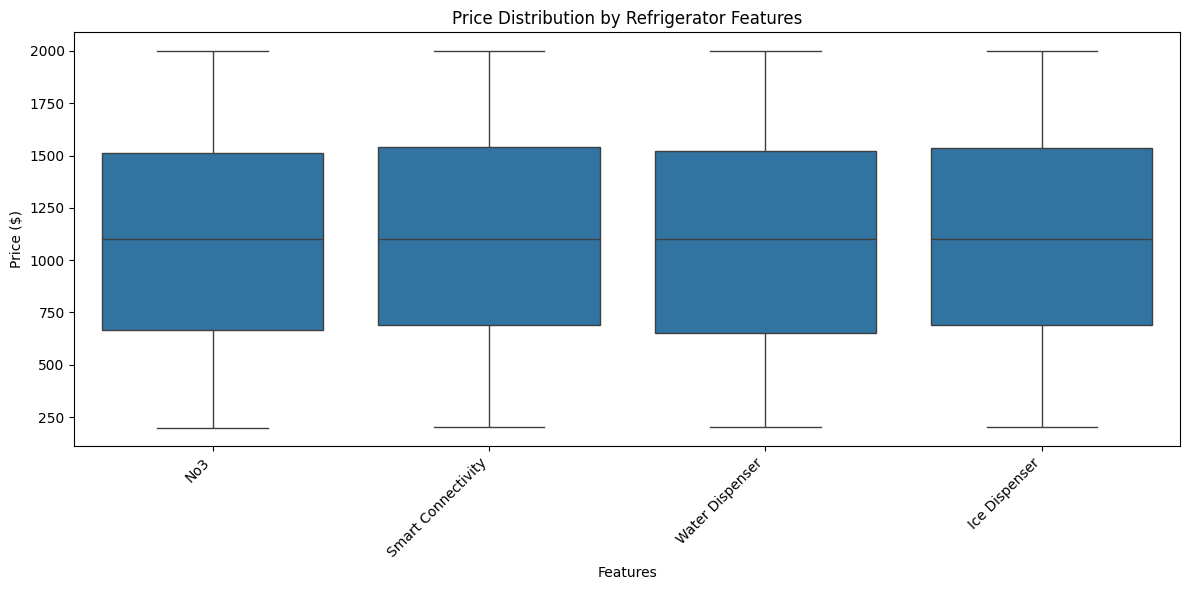

In [57]:
# Chart - 15 visualization code (Price vs Features Box Plot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=fp, x='Features', y='Price', order=fp['Features'].value_counts().index)
plt.title('Price Distribution by Refrigerator Features')
plt.xlabel('Features')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I chose a **Box Plot** to visualize the relationship between 'Features' (categorical) and 'Price' (numerical). A box plot is ideal for comparing the distribution of a numerical variable across different categories. It effectively shows the median, quartiles, and potential outliers for 'Price' within each 'Feature' category, allowing us to discern if certain features correlate with higher prices or greater price variability.

From the box plot of 'Price' vs. 'Features', we can observe:

*   **Price Differences by Feature**: Certain features (e.g., 'Smart Connectivity', 'Ice Dispenser') might be associated with higher median prices compared to basic models or those with 'No3' (unspecified features). This indicates the premium consumers are willing to pay for specific functionalities.
*   **Price Variability**: The spread of prices (interquartile range) within each feature category will show how consistent pricing is. Some features might be available across a wider price range (from budget to high-end), while others might be concentrated in premium segments.
*   **Outliers**: The presence of individual points beyond the whiskers could indicate unusually expensive or inexpensive models with specific features, potentially pointing to luxury offerings or promotional sales.
*   **'No3' Category**: The 'No3' category (missing features) will show its own price distribution, which might be broad if it includes a mix of various unclassified models, or might be skewed if it represents a particular segment of basic models.

Yes, insights from the 'Price' vs. 'Features' box plot can lead to significant positive business impacts:

*   **Product Feature Prioritization**: Manufacturers can identify which features command a premium in the market. This insight is crucial for prioritizing R&D, design, and inclusion of features in new models, focusing on those that deliver the most value and justify higher price points.
*   **Pricing Strategy**: Businesses can optimize pricing based on feature sets. They can determine competitive pricing for models with specific features and strategically price new products based on the value proposition of their included features.
*   **Marketing and Sales Messaging**: Marketing campaigns can be tailored to highlight features that strongly influence price, emphasizing their benefits and justifying the cost to consumers. Sales teams can leverage this information to upsell models with high-value features.
*   **Competitive Differentiation**: Understanding the feature-price landscape helps in identifying opportunities for differentiation. A business might introduce a unique, high-value feature that allows them to command a premium, or offer a popular feature at a more competitive price point.

**Insights that lead to negative growth:**

Misinterpreting or misapplying these insights can lead to negative growth:

*   **Feature Overload Without Justification**: If a business observes that 'Smart Connectivity' correlates with higher prices and decides to add numerous smart features to all products without understanding consumer demand or their willingness to pay, it could lead to increased production costs, higher prices, and products that are too complex or expensive for the target market. This can result in reduced sales and market share.
*   **Ignoring 'No3' (Basic Models)**: If 'No3' (unspecified features) represents a significant segment of budget-friendly refrigerators, a business might mistakenly assume that consumers always want more features. Neglecting the demand for basic, reliable, and affordable refrigerators could lead to a loss of market share to competitors who cater to this cost-conscious segment.
*   **Misjudging Value Perception**: A feature might be expensive to implement but perceived as low-value by consumers. For example, if a complex 'Ice Dispenser' system significantly drives up costs but consumers don't see a proportional increase in value compared to a simpler system, pricing the product higher solely due to this feature could result in poor sales and inventory buildup.

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***